<a href="https://colab.research.google.com/github/PreethiR091/Deep-Learning/blob/main/Preethi_R_24BAD091_DL_Ex_no_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EXPT NO: 3 - IMPLEMENTATION OF CONVOLUTIONAL NEURAL NETWORKS (CNNs) FOR IMAGE CLASSIFICATION

Task A: DATASET PREPARATION

    •	Perform the following tasks:
    •	Download an image dataset from Kaggle or use CIFAR-10.
    •	Load the dataset.
    •	Preprocess images by resizing and normalization.
    •	Split the dataset into training, validation, and testing sets.


Preethi R - 24BAD091
TensorFlow Version: 2.20.0

Original Dataset Shape
Training Images: (50000, 32, 32, 3)
Training Labels: (50000, 1)
Testing Images: (10000, 32, 32, 3)
Testing Labels: (10000, 1)

After Splitting
Training Images: (45000, 32, 32, 3)
Validation Images: (5000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


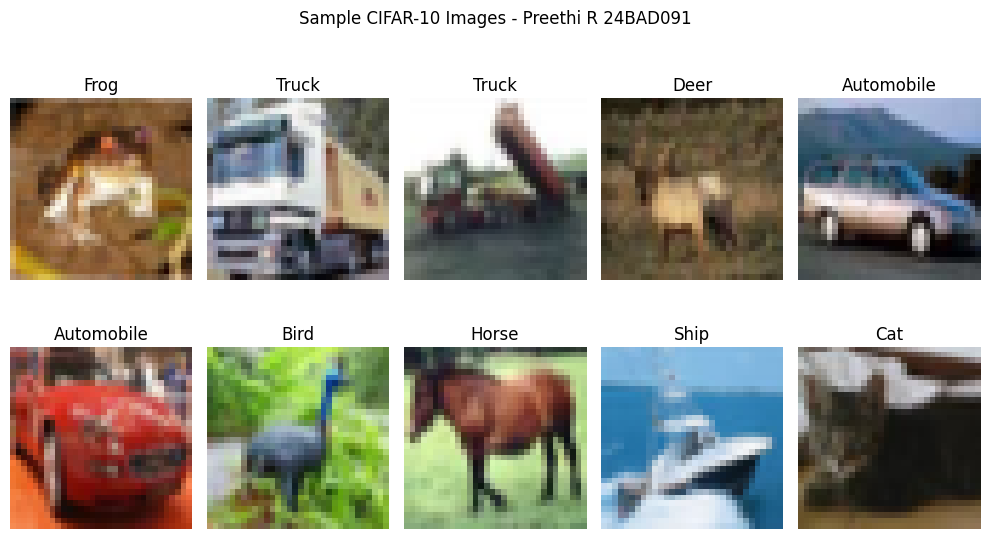


Dataset preprocessing completed successfully.


In [5]:
# EXPERIMENT NO: 3
# TASK A: DATASET PREPARATION
# Student Name: Preethi R
# Roll No: 24BAD091

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10

print("Preethi R - 24BAD091")
print("TensorFlow Version:", tf.__version__)

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("\nOriginal Dataset Shape")
print("Training Images:", x_train.shape)
print("Training Labels:", y_train.shape)
print("Testing Images:", x_test.shape)
print("Testing Labels:", y_test.shape)

# Normalize pixel values between 0 and 1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Create validation set
x_validation = x_train[-5000:]
y_validation = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("\nAfter Splitting")
print("Training Images:", x_train.shape)
print("Validation Images:", x_validation.shape)
print("Testing Images:", x_test.shape)

# CIFAR-10 class names
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

# Display sample images
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Images - Preethi R 24BAD091")
plt.tight_layout()
plt.show()

print("\nDataset preprocessing completed successfully.")

Task B: CNN MODEL IMPLEMENTATION

Build a CNN model consisting of:

    •	Convolution layers
    •	ReLU activation
    •	Max Pooling layers
    •	Fully Connected layers
    •	Softmax output layer

Compile the model using:

    •	Appropriate optimizer
    •	Cross-entropy loss function


In [6]:
# EXPERIMENT NO: 3
# TASK B: CNN MODEL IMPLEMENTATION
# Student Name: Preethi R
# Roll No: 24BAD091

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Input
from tensorflow.keras.optimizers import Adam

# Create CNN model
model = Sequential([
    Input(shape=(32, 32, 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Preethi R - 24BAD091")
print("\nCNN Model Summary")
print("=" * 60)

model.summary()

Preethi R - 24BAD091

CNN Model Summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Task C: MODEL TRAINING AND EVALUATION

Train the CNN model.

Record:

    •	Training accuracy
    •	Validation accuracy
    •	Training loss
    •	Validation loss
    •	Testing accuracy

Plot:

    •	Accuracy vs Epoch
    •	Loss vs Epoch




Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 82ms/step - accuracy: 0.4024 - loss: 1.6214 - val_accuracy: 0.5252 - val_loss: 1.3402
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 82ms/step - accuracy: 0.5508 - loss: 1.2609 - val_accuracy: 0.5650 - val_loss: 1.2482
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 59s 83ms/step - accuracy: 0.6103 - loss: 1.1051 - val_accuracy: 0.6236 - val_loss: 1.0772
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 85ms/step - accuracy: 0.6451 - loss: 1.0082 - val_accuracy: 0.6542 - val_loss: 0.9944
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 57s 82ms/step - accuracy: 0.6776 - loss: 0.9230 - val_accuracy: 0.6670 - val_loss: 0.9607

Model Evaluation
Final Training Accuracy: 0.6776000261306763
Final Validation Accuracy: 0.6669999957084656
Final Training Loss: 0.9229587912559509
Final Validation Loss: 0.9606677889823914
Testing Accuracy: 0.6603999733924866
Testing Loss: 0.9805741906166077


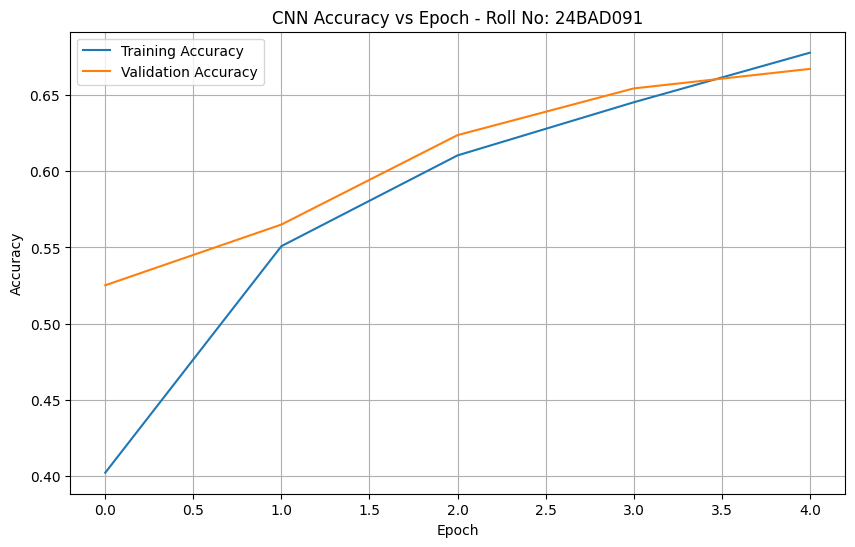

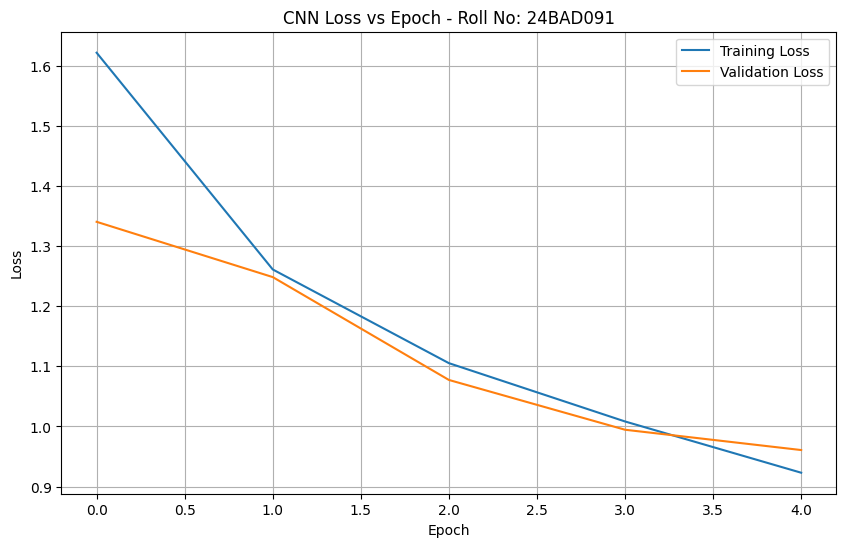

In [7]:
# EXPERIMENT NO: 3
# TASK C: MODEL TRAINING AND EVALUATION
# Student Name: Preethi R
# Roll No: 24BAD091

# Train the CNN model
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_validation, y_validation),
    verbose=1
)

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nModel Evaluation")
print("=" * 50)

print("Final Training Accuracy:",
      history.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Final Training Loss:",
      history.history["loss"][-1])

print("Final Validation Loss:",
      history.history["val_loss"][-1])

print("Testing Accuracy:", test_accuracy)
print("Testing Loss:", test_loss)

# Plot accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Accuracy vs Epoch - Roll No: 24BAD091")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Loss vs Epoch - Roll No: 24BAD091")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Task D: PERFORMANCE ANALYSIS

Analyze:

    •	Classification accuracy
    •	Confusion Matrix
    •	Sample predictions
    •	Misclassified images

Discuss the strengths and limitations of CNNs for image classification.



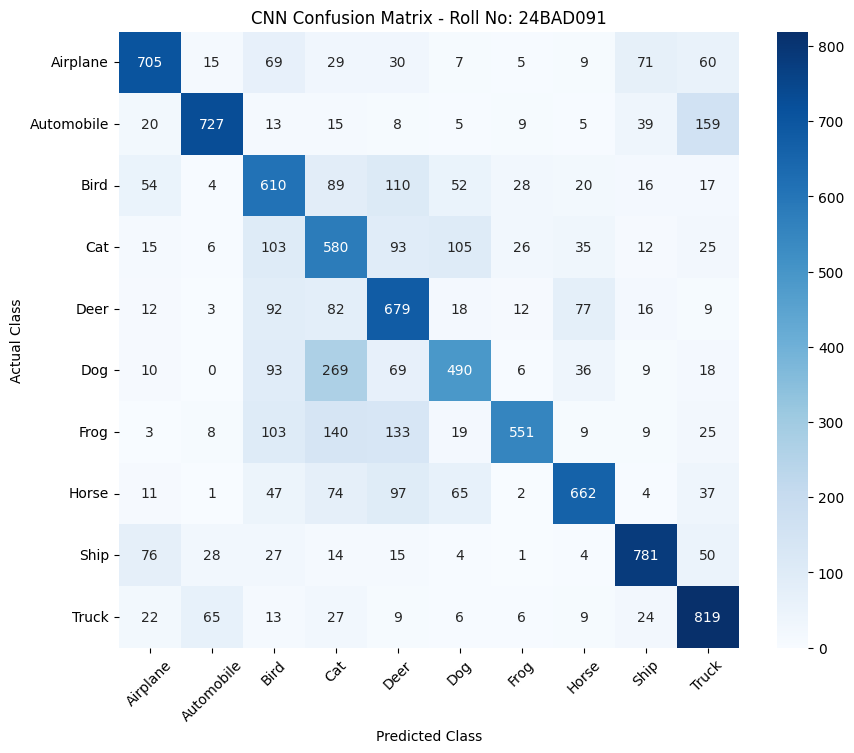


Classification Report
              precision    recall  f1-score   support

    Airplane       0.76      0.70      0.73      1000
  Automobile       0.85      0.73      0.78      1000
        Bird       0.52      0.61      0.56      1000
         Cat       0.44      0.58      0.50      1000
        Deer       0.55      0.68      0.61      1000
         Dog       0.64      0.49      0.55      1000
        Frog       0.85      0.55      0.67      1000
       Horse       0.76      0.66      0.71      1000
        Ship       0.80      0.78      0.79      1000
       Truck       0.67      0.82      0.74      1000

    accuracy                           0.66     10000
   macro avg       0.68      0.66      0.66     10000
weighted avg       0.68      0.66      0.66     10000



In [8]:
# EXPERIMENT NO: 3
# TASK D: PERFORMANCE ANALYSIS
# Student Name: Preethi R
# Roll No: 24BAD091

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Generate predictions
y_probability = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_probability, axis=1)
y_true = y_test.flatten()

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN Confusion Matrix - Roll No: 24BAD091")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# Classification report
print("\nClassification Report")
print("=" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

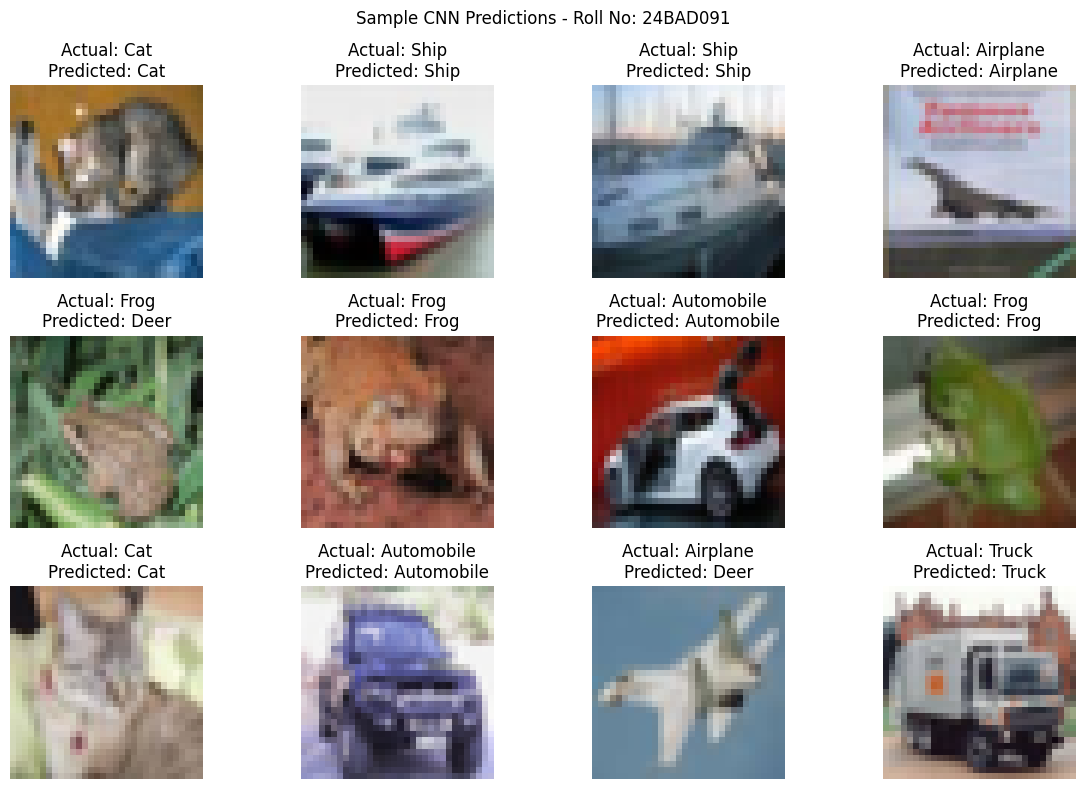

In [9]:
# Display sample predictions

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[i])

    actual = class_names[y_true[i]]
    predicted = class_names[y_pred[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis("off")

plt.suptitle("Sample CNN Predictions - Roll No: 24BAD091")
plt.tight_layout()
plt.show()